# Data Exploration



**Install libraries**

In [45]:
%pip install matplotlib
%pip install scikit-learn
%pip install xgboost
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


**Import libraries**

In [46]:
import pandas as pd # should already be installed on data_preprocess.ipynb
import matplotlib.pyplot as plt
import os

## Load data

Loading the data from the processed CSV file created in data_preprocess.ipynb

In [47]:
working_dir = os.getcwd()
order_forms_processed_dir = os.path.join(working_dir, "order_forms_processed")

df = pd.read_csv(os.path.join(order_forms_processed_dir, "order_forms_sorted.csv"))
df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)
df["Timestamp"] = df["Timestamp"].dt.tz_convert('US/Pacific') # convert to Pacific time
df.head()


,Unnamed: 0,Timestamp,TEA,FLAVOR,MILK,ICE [Ice Level],SWEETNESS [Sweetness Level],Toppings,NAME,Started,Completed,Form_ID
0,0,2022-10-20 19:02:40-07:00,THAI,NaN,MILK,50%,75%,BOBA,res - coop,TRUE,TRUE,10/14/2022 16:49:26
1,1,2022-10-20 19:05:44-07:00,SPECIAL,NaN,NaN,NaN,NaN,BOBA,sean,TRUE,TRUE,10/14/2022 16:49:26
2,2,2022-10-20 19:06:32-07:00,JSMN,NaN,MILK,50%,75%,LYCHEE,helin,TRUE,TRUE,10/14/2022 16:49:26
3,3,2022-10-20 19:07:23-07:00,SPECIAL,NaN,NaN,NaN,NaN,NaN,katie,TRUE,TRUE,10/14/2022 16:49:26
4,4,2022-10-20 19:08:09-07:00,TARO,NaN,Soy,NaN,100%,BOBA,andrea,TRUE,TRUE,10/14/2022 16:49:26


### Time Series Analysis
First, I'm curious about how the shape of orders changes from semester to semester. First, let's add semester data to the dataframe and look at the number of orders by school year and semester.

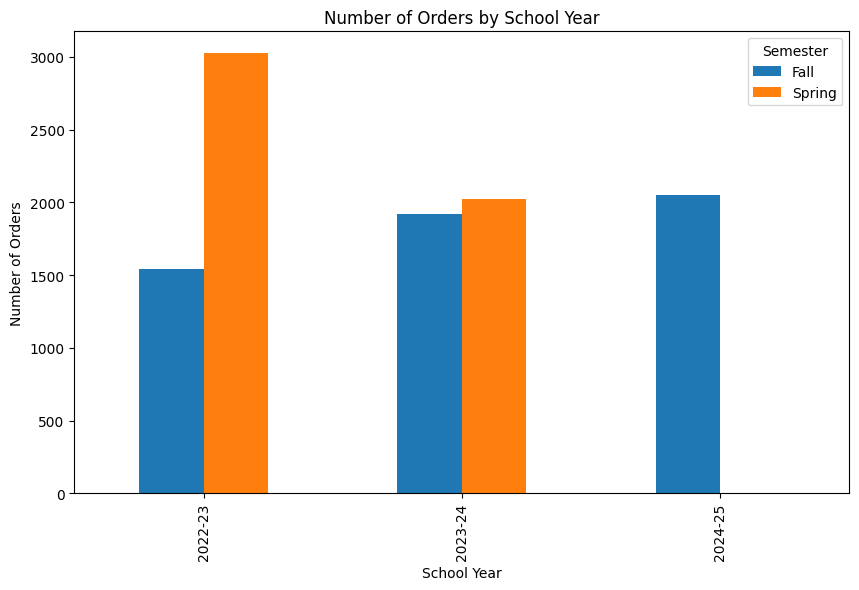

In [59]:
semesters_dict = {
    "Fall": "9-01",
    "Spring": "1-01",
}

df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day
df["Semester"] = df["Timestamp"].dt.month.apply(lambda x: "Fall" if x in [9, 10, 11, 12] else "Spring")

df["School_Year"] = df.apply(lambda x: 
    f"{x['Year']-1}-{str(x['Year'])[2:]}" if x["Semester"] == "Spring"
    else f"{x['Year']}-{str(x['Year']+1)[2:]}", 
    axis=1
)

# plot with school years
order = ["Fall", "Spring"]
df.groupby(["School_Year", "Semester"]).size().unstack()[order].plot(kind="bar", figsize=(10, 6))
plt.title("Number of Orders by School Year")
plt.xlabel("School Year")
plt.ylabel("Number of Orders")
plt.show()

Let's visualize the shape of orders for each of the 5 semesters with weeks on the x-axis and the number of orders on the y-axis.